<a href="https://colab.research.google.com/github/dataanalysis86powerbi-hash/dataanaysispowerbi.github.io/blob/main/Predicci%C3%B3n_precios_cierre_activos_financieros.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance --quiet  # Instala la biblioteca yfinance para obtener datos financieros de Yahoo Finance de forma silenciosa.

In [ ]:
# IMPORTACIÓN DE LIBRERÍAS
# ================================
import numpy as np  # Importa NumPy para operaciones numéricas y manipulación de arrays.
import pandas as pd  # Importa Pandas para manipulación y análisis de datos en DataFrames.
import matplotlib.pyplot as plt  # Importa Matplotlib para crear gráficos y visualizaciones.

import yfinance as yf  # Importa yfinance para descargar datos históricos de acciones y otros instrumentos.

from sklearn.preprocessing import MinMaxScaler  # Importa MinMaxScaler para normalizar los datos entre un rango (0, 1).
from sklearn.metrics import mean_squared_error, mean_absolute_error  # Importa métricas para evaluar el rendimiento del modelo.

from tensorflow.keras.models import Sequential  # Importa Sequential para crear modelos de red neuronal capa por capa.
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout  # Importa capas específicas: LSTM (memoria a largo y corto plazo), GRU (unidad recurrente con puerta), Dense (capa completamente conectada), Dropout (para regularización).
from tensorflow.keras.callbacks import EarlyStopping  # Importa EarlyStopping para detener el entrenamiento cuando la pérdida de validación deja de mejorar.

plt.style.use('default')  # Establece el estilo predeterminado para los gráficos de Matplotlib.

In [ ]:
# DESCARGA DE DATOS FINANCIEROS
# ================================
ticker = "AAPL"  # puedes cambiar por MSFT, TSLA, BTC-USD, etc.
start_date = "2015-01-01"
end_date = "2024-01-01"

data = yf.download(ticker, start=start_date, end=end_date)

data.head()

/tmp/ipython-input-2932140232.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.237555,24.705324,23.798604,24.694239,212818400
2015-01-05,23.554743,24.086803,23.368523,24.006994,257142000
2015-01-06,23.556961,23.816340,23.195602,23.619034,263188400
2015-01-07,23.887281,23.987042,23.654504,23.765350,160423600
2015-01-08,24.805082,24.862723,24.097885,24.215383,237458000


Price         Close
Ticker         AAPL
count   2264.000000
mean      81.394710
std       55.990879
min       20.604078
25%       32.814696
50%       51.220848
75%      139.017624
max      196.256546


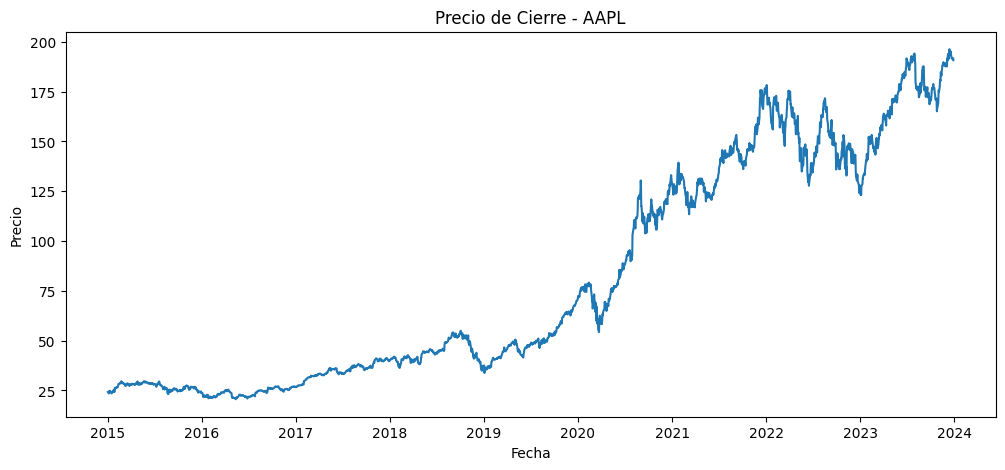

In [ ]:
#📌 PASO 3 – Selección y exploración de variables
# ================================
# SELECCIÓN DE VARIABLE OBJETIVO
# ================================
prices = data[['Close']]  # Selecciona solo la columna 'Close' (precio de cierre) del DataFrame 'data' como la variable objetivo.

print(prices.describe())  # Muestra un resumen estadístico descriptivo de los precios de cierre.

plt.figure(figsize=(12,5))  # Crea una nueva figura para el gráfico con un tamaño específico.
plt.plot(prices)  # Traza los precios de cierre a lo largo del tiempo.
plt.title(f'Precio de Cierre - {ticker}')  # Establece el título del gráfico, incluyendo el ticker de la acción.
plt.xlabel('Fecha')  # Establece la etiqueta del eje X como 'Fecha'.
plt.ylabel('Precio')  # Establece la etiqueta del eje Y como 'Precio'.
plt.show()  # Muestra el gráfico.

In [ ]:
#📌 PASO 4 – Preprocesamiento y normalización
# ================================
# NORMALIZACIÓN
# ================================
scaler = MinMaxScaler(feature_range=(0,1))  # Inicializa el escalador MinMaxScaler para normalizar los datos entre 0 y 1.
scaled_prices = scaler.fit_transform(prices)  # Ajusta el escalador a los precios y transforma los datos, escalándolos.

In [ ]:
#📌 PASO 5 – Creación de secuencias temporales
# ================================
# FUNCIÓN PARA CREAR VENTANAS TEMPORALES
# ================================
def create_sequences(data, window_size=60):  # Define una función para crear secuencias de datos con un tamaño de ventana.
    X, y = [], []  # Inicializa listas vacías para las secuencias de entrada (X) y las etiquetas (y).
    for i in range(window_size, len(data)):  # Itera a través de los datos, comenzando desde el tamaño de la ventana.
        X.append(data[i-window_size:i])  # Añade la secuencia de 'window_size' datos anteriores a X.
        y.append(data[i])  # Añade el dato actual (a predecir) a y.
    return np.array(X), np.array(y)  # Convierte las listas X e y a arrays de NumPy y los retorna.

WINDOW_SIZE = 60  # Define el tamaño de la ventana temporal (número de pasos de tiempo pasados para predecir el siguiente).

X, y = create_sequences(scaled_prices, WINDOW_SIZE)  # Llama a la función para crear las secuencias a partir de los precios escalados.

print(f"Shape X: {X.shape}")  # Imprime la forma (dimensiones) del array X.
print(f"Shape y: {y.shape}")  # Imprime la forma (dimensiones) del array y.

Shape X: (2204, 60, 1)
Shape y: (2204, 1)


In [ ]:
#📌 PASO 6 – Split Train / Test
# ================================
# DIVISIÓN TRAIN / TEST
# ================================
train_size = int(len(X) * 0.8)  # Calcula el tamaño del conjunto de entrenamiento (80% de los datos).

X_train, X_test = X[:train_size], X[train_size:]  # Divide X en conjuntos de entrenamiento y prueba.
y_train, y_test = y[:train_size], y[train_size:]  # Divide y en conjuntos de entrenamiento y prueba.

print("Train samples:", X_train.shape[0])  # Imprime el número de muestras en el conjunto de entrenamiento.
print("Test samples:", X_test.shape[0])  # Imprime el número de muestras en el conjunto de prueba.

Train samples: 1763
Test samples: 441


In [ ]:
#📌 PASO 7 – Diseño del modelo Deep Learning (LSTM + GRU)
# ================================
# ARQUITECTURA DEL MODELO
# ================================
model = Sequential([  # Inicializa un modelo secuencial de Keras (apila capas linealmente).
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),  # Añade una capa LSTM con 64 unidades, devuelve secuencias y define la forma de entrada.
    Dropout(0.2),  # Añade una capa Dropout con una tasa del 20% para regularización (previene el sobreajuste).
    GRU(32),  # Añade una capa GRU con 32 unidades.
    Dense(1)  # Añade una capa Dense (completamente conectada) con 1 unidad de salida (para la predicción de un único valor).
])

model.compile(  # Compila el modelo, configurando el optimizador y la función de pérdida.
    optimizer='adam',  # Utiliza el optimizador Adam, que es eficiente para una amplia gama de problemas.
    loss='mean_squared_error'  # Utiliza el error cuadrático medio como función de pérdida, común para regresión.
)

model.summary()  # Muestra un resumen de la arquitectura del modelo, incluyendo el número de parámetros.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,337 (102.88 KB)

 Trainable params: 26,337 (102.88 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#📌 PASO 8 – Entrenamiento del modelo
# ================================
# ENTRENAMIENTO
# ================================
early_stopping = EarlyStopping(  # Inicializa la llamada EarlyStopping para detener el entrenamiento si no hay mejora.
    monitor='val_loss',  # Monitorea la pérdida de validación para detectar mejoras.
    patience=10,  # Espera 10 épocas sin mejora antes de detener el entrenamiento.
    restore_best_weights=True  # Restaura los pesos del modelo a la época con la mejor pérdida de validación.
)

history = model.fit(  # Entrena el modelo con los datos de entrenamiento.
    X_train,  # Datos de entrada para el entrenamiento.
    y_train,  # Etiquetas de salida para el entrenamiento.
    validation_split=0.1,  # Utiliza el 10% de los datos de entrenamiento para validación.
    epochs=10,  # El número máximo de épocas para entrenar el modelo.
    batch_size=32,  # El número de muestras por actualización de gradiente.
    callbacks=[early_stopping],  # Aplica la llamada EarlyStopping durante el entrenamiento.
    verbose=1  # Muestra el progreso del entrenamiento por época.
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 68ms/step - loss: 0.0155 - val_loss: 8.7030e-04
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 4.8535e-04 - val_loss: 8.6212e-04
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 4.7967e-04 - val_loss: 8.5228e-04
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 3.5518e-04 - val_loss: 8.2364e-04
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - loss: 3.6238e-04 - val_loss: 8.1172e-04
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 3.4127e-04 - val_loss: 0.0024
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - loss: 3.9749e-04 - val_loss: 8.1176e-04
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 2.7785e-04 - val_loss: 7.7914e-04
Epoch 9/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - loss: 2.4748e-04 - val_loss: 0.0011
Epoch 10/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - loss: 2.5807e-04 - val_loss: 9.6863e-04


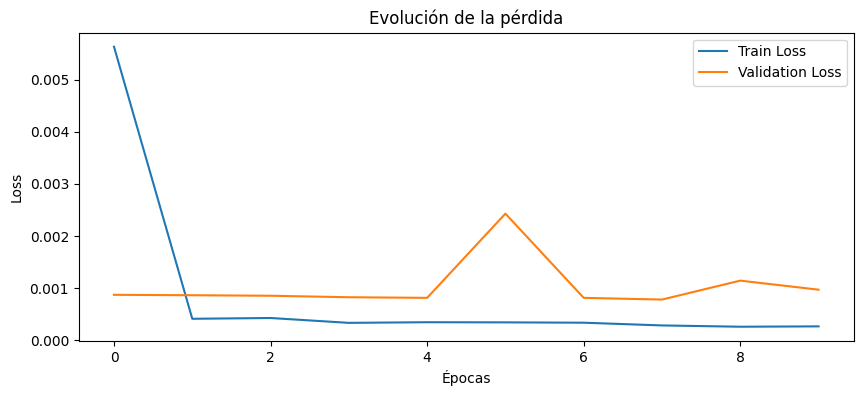

In [ ]:
#📌 PASO 9 – Curvas de entrenamiento
# ================================
# VISUALIZACIÓN DE LOSS
# ================================
plt.figure(figsize=(10,4))  # Crea una figura para el gráfico con un tamaño específico.
plt.plot(history.history['loss'], label='Train Loss')  # Traza la pérdida de entrenamiento a lo largo de las épocas.
plt.plot(history.history['val_loss'], label='Validation Loss')  # Traza la pérdida de validación a lo largo de las épocas.
plt.title('Evolución de la pérdida')  # Establece el título del gráfico.
plt.xlabel('Épocas')  # Etiqueta el eje X como 'Épocas'.
plt.ylabel('Loss')  # Etiqueta el eje Y como 'Loss'.
plt.legend()  # Muestra la leyenda del gráfico.
plt.show()  # Muestra el gráfico.

In [ ]:
#📌 PASO 10 – Predicciones y desnormalización
# ================================
# PREDICCIÓN
# ================================
predictions = model.predict(X_test)  # Realiza predicciones utilizando el modelo entrenado en los datos de prueba.

predictions_inv = scaler.inverse_transform(predictions)  # Desnormaliza las predicciones para obtener los valores originales de precio.
y_test_inv = scaler.inverse_transform(y_test)  # Desnormaliza los valores reales de prueba para compararlos con las predicciones.

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step


In [ ]:
# PASO 11 – Evaluación cuantitativa
# ================================
# MÉTRICAS DE EVALUACIÓN
# ================================
rmse = np.sqrt(mean_squared_error(y_test_inv, predictions_inv))  # Calcula el Error Cuadrático Medio (RMSE).
mae = mean_absolute_error(y_test_inv, predictions_inv)  # Calcula el Error Absoluto Medio (MAE).

print(f"RMSE: {rmse:.2f}")  # Imprime el valor de RMSE formateado a dos decimales.
print(f"MAE : {mae:.2f}")  # Imprime el valor de MAE formateado a dos decimales.

RMSE: 5.16
MAE : 4.18


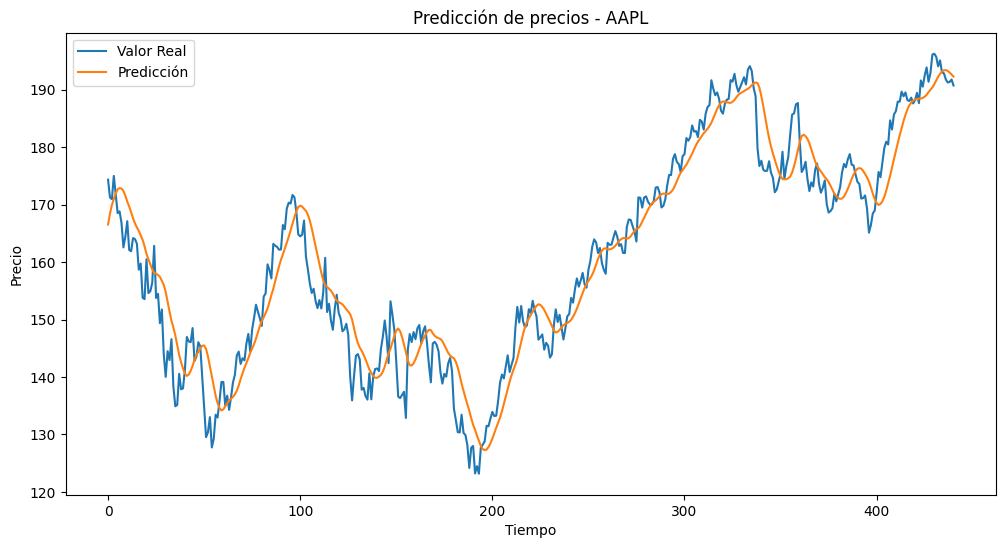

In [ ]:
#📌 PASO 12 – Visualización de resultados finales
# ================================
# COMPARACIÓN REAL VS PREDICCIÓN
# ================================
plt.figure(figsize=(12,6))  # Crea una figura para el gráfico con un tamaño específico.
plt.plot(y_test_inv, label='Valor Real')  # Traza los valores reales desnormalizados.
plt.plot(predictions_inv, label='Predicción')  # Traza los valores predichos desnormalizados.
plt.title(f'Predicción de precios - {ticker}')  # Establece el título del gráfico, incluyendo el ticker.
plt.xlabel('Tiempo')  # Etiqueta el eje X como 'Tiempo'.
plt.ylabel('Precio')  # Etiqueta el eje Y como 'Precio'.
plt.legend()  # Muestra la leyenda del gráfico.
plt.show()  # Muestra el gráfico.

In [ ]:
# DESCARGA DE DATOS FINANCIEROS
# ================================
ticker = "AAPL"  # Define el símbolo de cotización de la acción que se va a analizar (Apple en este caso).
start_date = "2015-01-01"  # Establece la fecha de inicio para la descarga de datos.
end_date = "2024-01-01"  # Establece la fecha de fin para la descarga de datos.

data = yf.download(ticker, start=start_date, end=end_date)  # Descarga los datos históricos del ticker especificado entre las fechas dadas.

data.head()  # Muestra las primeras 5 filas del DataFrame descargado para una inspección rápida.

/tmp/ipython-input-1537087140.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start_date, end=end_date)  # Descarga los datos históricos del ticker especificado entre las fechas dadas.
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2015-01-02,24.237555,24.705324,23.798604,24.694239,212818400
2015-01-05,23.554743,24.086803,23.368523,24.006994,257142000
2015-01-06,23.556961,23.816340,23.195602,23.619034,263188400
2015-01-07,23.887281,23.987042,23.654504,23.765350,160423600
2015-01-08,24.805082,24.862723,24.097885,24.215383,237458000
